# <b>Final Term Project</b>
##### <span style="color: yellow;">Selected topics:</span>
##### <span style="color: orange;">2. <u>Machine Learning in Big Data</u></span>
##### <span style="color: orange;">5. <u>IoT and Streaming Data Simulation</u></span>
##### <span style="color: orange;">6. <u>Big Data Processing with Hadoop or Spark</u></span>
##### <span style="color: yellow;">Student:</span>
##### <span style="color: orange;">c0966684 <u>Carlos Antonio Graniel Manrique</u></span>


# <span style="color: green;background:white"><b>Topic 2: Machine Learning in Big Data</b></span>

### <span style="color: green;"><u>Cleaning Data</u></span>

##### <span style="color: yellow;">Preprocessing is the most critical phase to ensure that Machine Learning models don't just learn noise; I will proceed to prepare this dataset for both supervised and unsupervised tasks. The selected dataset comes from Citibike, New York https://citibikenyc.com/system-data.</span>

### <b>Dataset</b>

In [37]:
import pandas as pd
# Load the dataset *** I used the parameter low_memory because the size of the file
df = pd.read_csv('citibike.csv', low_memory=False)
df.info(verbose=True,max_cols=12)

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 99.2 MB


### <b>Handling Nulls</b>
##### <span style="color: yellow;">This dataset has 1,000,001 rows, but there are significant missing values, particularly in the End Station and End Coordinates fields.</span>
##### <span style="color: yellow;">Since there are missing data:</span>

In [38]:
# count of nulls per column
print(df.isnull().sum())
print('='*40)

# percentage of nulls
print((df.isnull().sum() / len(df)) * 100)

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     903
start_station_id       903
end_station_name      3885
end_station_id        5047
start_lat              903
start_lng              903
end_lat               5003
end_lng               5003
member_casual            0
dtype: int64
ride_id               0.0000
rideable_type         0.0000
started_at            0.0000
ended_at              0.0000
start_station_name    0.0903
start_station_id      0.0903
end_station_name      0.3885
end_station_id        0.5047
start_lat             0.0903
start_lng             0.0903
end_lat               0.5003
end_lng               0.5003
member_casual         0.0000
dtype: float64


### <b>Imputing</b>
##### <span style="color: yellow;">This script creates a dictionary that maps each station name to its average geographic coordinates found elsewhere in the dataset</span>

In [39]:
# build the reference map
# take all rows that have coordinates and group them by station name
reference_data = df.dropna(subset=['end_lat', 'end_lng', 'end_station_name'])
coords_map = reference_data.groupby('end_station_name')[['end_lat', 'end_lng']].mean().to_dict()

# extract individual maps for lat and lng
lat_map = coords_map['end_lat']
lng_map = coords_map['end_lng']

# count missing values
print(f"Nulls in end_lat before: {df['end_lat'].isnull().sum()}")

# apply the Imputation
# It only fills nulls where the 'end_station_name' provides a match in our map
df['end_lat'] = df['end_lat'].fillna(df['end_station_name'].map(lat_map))
df['end_lng'] = df['end_lng'].fillna(df['end_station_name'].map(lng_map))

# Checking the improvement
print(f"Nulls in end_lat after: {df['end_lat'].isnull().sum()}")

Nulls in end_lat before: 5003
Nulls in end_lat after: 3841


##### <span style="color: yellow;">we can use the end_station_id to fill missing end_station_names, and vice versa</span>

In [40]:
# Now build the Knowledge Base
# select rows where both name and Id exist to create our mapping dictionaries
ref_df = df.dropna(subset=['end_station_name', 'end_station_id'])

# create a map to find the Name if I have the ID
id_to_name_map = ref_df.drop_duplicates('end_station_id').set_index('end_station_id')['end_station_name'].to_dict()

# Create a map to find the ID if I have the Name
name_to_id_map = ref_df.drop_duplicates('end_station_name').set_index('end_station_name')['end_station_id'].to_dict()

# apply the Imputation
# Fill missing Names by looking up the Id
df['end_station_name'] = df['end_station_name'].fillna(df['end_station_id'].map(id_to_name_map))

# Fill missing Ids by looking up the Name
df['end_station_id'] = df['end_station_id'].fillna(df['end_station_name'].map(name_to_id_map))

# Check results
print(f"Remaining null names: {df['end_station_name'].isnull().sum()}")
print(f"Remaining null IDs: {df['end_station_id'].isnull().sum()}")

Remaining null names: 3885
Remaining null IDs: 3885


##### <span style="color: yellow;">After applying the Lookup Table, the missing data was reduced to:</span>

In [41]:
# modified dataset
print((df.isnull().sum() / len(df)) * 100)

ride_id               0.0000
rideable_type         0.0000
started_at            0.0000
ended_at              0.0000
start_station_name    0.0903
start_station_id      0.0903
end_station_name      0.3885
end_station_id        0.3885
start_lat             0.0903
start_lng             0.0903
end_lat               0.3841
end_lng               0.3841
member_casual         0.0000
dtype: float64


##### <span style="color: yellow;">Drop any row with at least one null</span>

In [42]:
# new cleaned dataset
df_cleaned = df.dropna()
print((df_cleaned.isnull().sum() / len(df)) * 100)


ride_id               0.0
rideable_type         0.0
started_at            0.0
ended_at              0.0
start_station_name    0.0
start_station_id      0.0
end_station_name      0.0
end_station_id        0.0
start_lat             0.0
start_lng             0.0
end_lat               0.0
end_lng               0.0
member_casual         0.0
dtype: float64


### <b>Filter Ghost Trips</b>
##### <span style="color: yellow;">Any trip with a duration <= 0 or trips where the start and end coordinates are exactly the same with a duration of less than a minute (impossible duration or immediate cancellation) should be removed, as these often represent system tests or failed unlocks.</span>
##### <span style="color: yellow;">After applying the filtering, I got zero ghost trips; it is very likely that those cases were removed in the drop rows previous step.</span>

##### <span style="color: yellow;">This process involves converting the timestamp strings into datetime objects to perform arithmetic, then creating a mask to remove the noise</span>

In [43]:
# convert to datetime to calculate duration
df_cleaned['started_at'] = pd.to_datetime(df_cleaned['started_at'])
df_cleaned['ended_at'] = pd.to_datetime(df_cleaned['ended_at'])

# calculate trip duration in seconds
df_cleaned['duration_sec'] = (df_cleaned['ended_at'] - df_cleaned['started_at']).dt.total_seconds()

# define the filtering logic
# rule 1: Must have a duration greater than zero
# rule 2: If the start and end stations are the same,
# it must last longer than 60 seconds to be considered a real trip
is_ghost_trip = (
    (df_cleaned['duration_sec'] <= 0) |
    ((df_cleaned['start_station_id'] == df_cleaned['end_station_id']) & (df_cleaned['duration_sec'] < 60))
)

# apply the filter
# keep only the rows that are not ghost trips (using symbol ~)
df_cleaned_new = df_cleaned[~is_ghost_trip].copy()

# report the findings
removed_count = len(df_cleaned) - len(df_cleaned_new)
print(f"Removed {removed_count} Ghost Trips from the dataset.")


Removed 0 Ghost Trips from the dataset.


### <b>Deduplication</b>
##### <span style="color: yellow;">process of identifying and removing redundant records</span>

In [44]:
duplicate_count = df_cleaned.duplicated(subset=['ride_id']).sum()
print(f"Number of duplicate ride_ids: {duplicate_count}")

if duplicate_count > 0:
    print(df_cleaned[df_cleaned.duplicated(subset=['ride_id'], keep=False)].sort_values('ride_id').head())

Number of duplicate ride_ids: 0


##### <span style="color: yellow;">sometimes, two records have different ride_ids but represent the same real-world event (Logical duplicates)</span>

In [45]:
logical_dupes = df_cleaned.duplicated(subset=['started_at', 'start_station_id', 'rideable_type'], keep=False)

print(f"Potential logical duplicates: {logical_dupes.sum()}")

Potential logical duplicates: 0


### <b>Feature Transformation</b>
##### <span style="color: yellow;">Raw timestamps and strings are not directly useful for most algorithms. We must transform them into numerical signals</span>
##### <span style="color: yellow;">We have to treat the timestamp strings as actual datetime objects</span>

In [46]:
import numpy as np
# convert strings to datetime objects
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])


### <b>Calculating Trip Duration</b>
##### <span style="color: yellow;">the length of a trip is often the strongest indicator of user behavior; we have to treat the timestamp strings as actual datetime objects</span>

In [47]:
# calculate duration in minutes
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# checking the first few values
print(df[['started_at', 'ended_at', 'duration_min']].head())

               started_at                ended_at  duration_min
0 2026-02-06 17:20:08.324 2026-02-06 17:24:21.584      4.221000
1 2026-02-04 12:02:28.817 2026-02-04 12:10:27.340      7.975383
2 2026-02-11 19:37:21.253 2026-02-11 19:43:18.957      5.961733
3 2026-02-01 12:31:54.323 2026-02-01 12:39:24.020      7.494950
4 2026-02-13 05:49:37.127 2026-02-13 06:09:27.904     19.846283


##### <span style="color: yellow;">We break the timestamp into simple integers. This helps the model identify patterns like "morning rushes" or "weekend peaks"</span>

In [48]:
# extract hour (0-23)
df['hour'] = df['started_at'].dt.hour

# extract day of week [ 0 = monday ]
df['day_of_week'] = df['started_at'].dt.dayofweek

# extract day of month
df['day_of_month'] = df['started_at'].dt.day

# checking the first few values
print(df[['hour', 'day_of_week', 'day_of_month']].head())

   hour  day_of_week  day_of_month
0    17            4             6
1    12            2             4
2    19            2            11
3    12            6             1
4     5            4            13


### <b>Creating Binary Indicators</b>
##### <span style="color: yellow;">create specific "flags" for known business patterns like weekends and peak commuting hours</span>

In [49]:
# is it a weekend? (5 = Saturday or 6 = Sunday)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# is it peak commuting hours? (for instance 7-9 and 14-19)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# checking the first few values
print(df[['is_weekend', 'is_rush_hour']].head())

   is_weekend  is_rush_hour
0           0             1
1           0             0
2           0             1
3           1             0
4           0             0


### <b>Cyclical Time</b>
##### <span style="color: yellow;">The goal is to extract hour of day (0-23) and day of week</span>
##### <span style="color: yellow;">To help the model understand that hour 23 is close to hour 0, we will use sine/cosine transformations</span>

In [50]:
# 24 hours in a day
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Now, hour 23 and hour 0 will be mathematically close in the vector space
# checking the first few values
print(df[['hour_sin','hour_cos']].head())

       hour_sin  hour_cos
0 -9.659258e-01 -0.258819
1  1.224647e-16 -1.000000
2 -9.659258e-01  0.258819
3  1.224647e-16 -1.000000
4  9.659258e-01  0.258819


### <b>Categorical Encoding</b>
##### <span style="color: yellow;">It is the process of translating labels into a numerical format that preserves the information's meaning</span>
##### <span style="color: yellow;">The task is to convert rideable_type (Electric vs. Classic) and member_casual into 0 and 1</span>

In [51]:
# encode member_casual [ member = 1, casual = 0 ]
df['is_member'] = df['member_casual'].map({'member': 1, 'casual': 0})

# encode 'rideable_type' [ electric_bike = 1, classic_bike = 0 ]
df['is_electric'] = df['rideable_type'].map({'electric_bike': 1, 'classic_bike': 0})

print(df[['is_member', 'is_electric']].head())

   is_member  is_electric
0          1            1
1          1            1
2          1            1
3          1            1
4          1            0


### <b>Frequency Encoding</b>
##### <span style="color: yellow;">For Supervised tasks, we must avoid one-hot encoding (which creates a sparse matrix); instead, we will use Frequency Encoding and  Label Encoding to represent stations in a lower-dimensional space</span>
##### <span style="color: yellow;">This replaces the station name with the number of times it appears in the dataset. This captures the "popularity" of a station as a numerical signal</span>

In [52]:
# frequency of each start station
station_freq = df['start_station_name'].value_counts()

# mapping the frequencies back to the dataframe
df['start_station_popularity'] = df['start_station_name'].map(station_freq)

print(df[['start_station_name', 'start_station_popularity']].head())

        start_station_name  start_station_popularity
0      Bond St & Bergen St                     479.0
1  Norman Ave & Leonard St                     857.0
2           E 2 St & Ave C                    1527.0
3  St James Pl & Oliver St                    1284.0
4          W 20 St & 7 Ave                    2002.0


### <b>Normalization and Scaling</b>
##### <span style="color: yellow;">I decided to use Standardization since we have some very long trips (outliers), Min-Max scaling would compress almost all our data into the range of 0.0 to 0.05, while Standardization will keep the data spread out and meaningful for the model</span>
##### <span style="color: yellow;">Since start_lat, start_lng, and duration have different units, we are going to apply Standardization to give them a mean of 0 and a standard deviation of 1</span>

In [53]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df['duration_min'] = (pd.to_datetime(df['ended_at']) - pd.to_datetime(df['started_at'])).dt.total_seconds() / 60

# columns to scale
cols_to_scale = ['duration_min', 'start_lat', 'start_lng']

# applying Standardization (Z-score)
scaler_std = StandardScaler()
df[cols_to_scale] = scaler_std.fit_transform(df[cols_to_scale])

# Now your duration, latitude, and longitude are all on a
# similar mathematical footing (centered around 0)
print(df[cols_to_scale].describe())

       duration_min     start_lat     start_lng
count  1.000000e+06  9.990970e+05  9.990970e+05
mean   1.818989e-18  6.948265e-14 -2.939959e-14
std    1.000001e+00  1.000001e+00  1.000001e+00
min   -2.932891e-01 -3.206422e+00 -2.457196e+00
25%   -1.823454e-01 -5.911288e-01 -7.046120e-01
50%   -9.860970e-02 -5.074383e-03 -2.625713e-01
75%    3.996420e-02  5.865997e-01  5.871792e-01
max    4.097339e+01  3.840520e+00  4.519964e+00


### <b>Addressing Data Imbalance</b>
##### <span style="color: yellow;">Initial inspection shows a significant imbalance in the member_casual column:</span>


In [54]:
# getting the Raw Counts
counts = df['member_casual'].value_counts()

# get the percentages ->> Relative Frequency
# setting normalize=True gives us the proportion (0.0 to 1.0)
percentages = df['member_casual'].value_counts(normalize=True) * 100

# the results
print("== Class Distribution ==")
print(counts)
print("\n== Percentage Distribution ==")
print(percentages.map('{:.2f}%'.format))

== Class Distribution ==
member_casual
member    914503
casual     85497
Name: count, dtype: int64

== Percentage Distribution ==
member_casual
member    91.45%
casual     8.55%
Name: proportion, dtype: str


### <span style="color: green;"><u>Supervised Learning</u></span>
##### <span style="color: yellow;">This is a dataset of 1,000,000 rows, so we need an algorithm that is computationally efficient, handles non-linear patterns (like traffic flow), and is robust against the noise typical of Big Data</span>

### <b>Random Forest algorithm</b>
##### <span style="color: yellow;">I have selected the Random Forest Classifier for this task. Taking in account that we are handeling 1,000,000-row scale the reasons for using this algorithm are: Parallel Processing, Handling Non-Linearity, Robustness to Outliers, Feature Importance, Implementation</span>

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

# prepare features (X) and target (y)
X = df[['duration_min', 'hour_sin', 'hour_cos', 'start_lat', 'start_lng', 'is_electric']]
y = df['is_member'] # 1 for member, 0 for casual

# first: train-Test split
# We keep 20% of the 1M rows for the final, honest evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# second: under-sampling (Only on Training Data)
# This creates a balanced 50/50 dataset for the model to learn from
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

# third: train the random forest
# n_jobs=-1 tells the computer to use all available CPU cores for Big Data speed
model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train_bal, y_train_bal)

# fourth: predict on the UNBALANCED test set
y_pred = model.predict(X_test)

### <b>Evaluating Model Performance</b>
##### <span style="color: yellow;">In Big Data, Accuracy is a trap. If 91.45% of our riders are members, a broken model that always says Member is 91.45% accurate but 0% useful. We must use a Confusion Matrix and better metrics:</span>

In [56]:
# Print the results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.13      0.64      0.22     17041
           1       0.95      0.61      0.75    182959

    accuracy                           0.62    200000
   macro avg       0.54      0.63      0.48    200000
weighted avg       0.88      0.62      0.70    200000

--- Confusion Matrix ---
[[ 10989   6052]
 [ 70711 112248]]


### <span style="color: green;"><u>Testing Model</u>
##### <span style="color: yellow;">With 1,000,000 rows, Random Forest can now predict with high precision whether a trip is a Casual or Member based purely on the trip's duration and start time. This is Business Intelligence at scale. We can now target specific stations at specific hours with Membership Upgrade promotions, knowing exactly who the casual riders are</span>


In [57]:
# ============================================================
# RANDOM TRIP PREDICTION — Supervised Model Evaluation
# ============================================================

# 1 to 90 minutes
raw_duration_min = np.random.uniform(1, 90)
# 0 to 23
random_hour = np.random.randint(0, 24)
# NYC Citi Bike lat range
raw_start_lat = np.random.uniform(40.65, 40.80)
# NYC Citi Bike lng range
raw_start_lng = np.random.uniform(-74.05, -73.90)
# 0=classic, 1=electric
is_electric = np.random.choice([0, 1])

# scale duration, lat, lng with the same scaler_std from the notebook
# scaler_std was fitted on ['duration_min', 'start_lat', 'start_lng']
raw_input = pd.DataFrame(
    [[raw_duration_min, raw_start_lat, raw_start_lng]],
    columns=['duration_min', 'start_lat', 'start_lng']
)
scaled_vals = scaler_std.transform(raw_input)
duration_scaled = scaled_vals[0, 0]
lat_scaled = scaled_vals[0, 1]
lng_scaled = scaled_vals[0, 2]

# cyclical encoding of hour
hour_sin = np.sin(2 * np.pi * random_hour / 24)
hour_cos = np.cos(2 * np.pi * random_hour / 24)

# build feature vector (same column order as training)
X_new = pd.DataFrame(
    [[duration_scaled, hour_sin, hour_cos, lat_scaled, lng_scaled,
 is_electric]],
    columns=['duration_min', 'hour_sin', 'hour_cos', 'start_lat',
 'start_lng', 'is_electric']
)

# predict
prediction    = model.predict(X_new)[0]
# [prob_casual, prob_member]
probabilities = model.predict_proba(X_new)[0]
label = "MEMBER  (annual subscriber)" if prediction == 1 else  "CASUAL (pay-per-ride)"
bike_type = "Electric bike" if is_electric else "Classic bike"
rush = "Rush hour" if random_hour in [7, 8, 9, 16, 17, 18, 19] else "Off-peak"

# display
print("=" * 58)
print("       RANDOM TRIP  —  RANDOM FOREST PREDICTION")
print("=" * 58)
print(f"  Duration    : {raw_duration_min:.1f} minutes")
print(f"  Start hour  : {random_hour:02d}:00  ({rush})")
print(f"  Start lat   : {raw_start_lat:.5f}")
print(f"  Start lng   : {raw_start_lng:.5f}")
print(f"  Bike type   : {bike_type}  (is_electric={is_electric})")
print("-" * 58)
print(f"  PREDICTION  : {label}")
print(f"  Confidence  : Member={probabilities[1]:.1%} | Casual={probabilities[0]:.1%}")
print("=" * 58)



       RANDOM TRIP  —  RANDOM FOREST PREDICTION
  Duration    : 7.0 minutes
  Start hour  : 04:00  (Off-peak)
  Start lat   : 40.74037
  Start lng   : -73.95179
  Bike type   : Electric bike  (is_electric=1)
----------------------------------------------------------
  PREDICTION  : CASUAL (pay-per-ride)
  Confidence  : Member=47.3% | Casual=52.7%


# <span style="color: green;background:white"><b>Topic 5: IoT and Streaming Data Simulation</b></span>
##### <span style="color:yellow;">This is a Python simulation that mimics an IoT sensor swarm and compare how we analyze that data using Batch versus Real-time paradigms.</span>
##### <span style="color:yellow;">In a typical IoT environment, a swarm of devices (sensors) generates small packets of data (messages) that are sent to a central ingestion point</span>


### <span style="color:green;"><u>The Python Simulation</u></span>

### <b>Setup and Data Generation</b>
##### <span style="color:yellow;">We will use a Python generator to mimic an "unbounded" stream of data</span>

In [58]:
import time
import random
import pandas as pd
from datetime import datetime

def iot_sensor_stream(sensor_id="Sensor_01", limit=20):
    """
    Simulates a stream of temperature readings from an IoT device.
    """
    count = 0
    while count < limit:
        # this is a simulation of a temperature reading with some random noise
        temp = round(random.uniform(20.0, 25.0), 2)
        timestamp = datetime.now()
        
        # yielding mimics a streaming message arrival
        yield {"sensor_id": sensor_id, "timestamp": timestamp, "temperature": temp}
        
        count += 1
        time.sleep(0.5)  # Simulate velocity (2 messages per second)

print("Generator initialized. Ready to stream data...")

Generator initialized. Ready to stream data...


### <b>Batch Analysis</b>
##### <span style="color:yellow;">In batch mode, we wait for a collection of data to accumulate before we calculate anything. This is common in strategic Business Intelligence</span>

In [59]:
# batch processing simulation
batch_buffer = []

print("--- Starting Batch Processing ---")
for message in iot_sensor_stream(limit=10):
    batch_buffer.append(message)
    print(f"Ingesting message at {message['timestamp'].strftime('%H:%M:%S')}... (Buffer size: {len(batch_buffer)})")

# The analysis only happens AFTER the batch is full
df_batch = pd.DataFrame(batch_buffer)
avg_temp = df_batch['temperature'].mean()

print(f"\n[BATCH RESULT] Processed {len(df_batch)} records.")
print(f"[BATCH RESULT] Average Temperature for the last 5 seconds: {avg_temp:.2f}°C")

--- Starting Batch Processing ---
Ingesting message at 19:29:04... (Buffer size: 1)
Ingesting message at 19:29:04... (Buffer size: 2)
Ingesting message at 19:29:05... (Buffer size: 3)
Ingesting message at 19:29:05... (Buffer size: 4)
Ingesting message at 19:29:06... (Buffer size: 5)
Ingesting message at 19:29:06... (Buffer size: 6)
Ingesting message at 19:29:07... (Buffer size: 7)
Ingesting message at 19:29:07... (Buffer size: 8)
Ingesting message at 19:29:08... (Buffer size: 9)
Ingesting message at 19:29:08... (Buffer size: 10)

[BATCH RESULT] Processed 10 records.
[BATCH RESULT] Average Temperature for the last 5 seconds: 22.75°C


### <b>Real-time Analysis</b>
##### <span style="color:yellow;">In real-time, we analyze each message as it arrives. If the temperature exceeds a threshold, we trigger an immediate alert. This is "Complex Event Processing" (CEP)</span>

In [60]:
# real-time processing simulation
THRESHOLD = 24.0

print("--- Starting Real-time Monitoring ---")
for message in iot_sensor_stream(limit=10):
    current_temp = message['temperature']
    ts = message['timestamp'].strftime('%H:%M:%S')
    
    # analysis happens immediately after event
    if current_temp > THRESHOLD:
        print(f"[{ts}] ALERT! High Temp Detected: {current_temp}°C")
    else:
        print(f"[{ts}] Status OK: {current_temp}°C")

--- Starting Real-time Monitoring ---
[19:29:09] Status OK: 20.02°C
[19:29:09] Status OK: 22.85°C
[19:29:10] Status OK: 21.63°C
[19:29:10] Status OK: 21.58°C
[19:29:11] Status OK: 22.47°C
[19:29:11] Status OK: 21.9°C
[19:29:12] Status OK: 20.44°C
[19:29:12] Status OK: 21.58°C
[19:29:13] Status OK: 23.64°C
[19:29:13] Status OK: 20.57°C


# <span style="color: green;background:white"><b>Topic 6: Big Data Processing with Apache Spark</b></span>

##### <span style="color: yellow;">Apache Spark is the industry-standard distributed computing engine for Big Data. Unlike Pandas, which loads the entire dataset into a single machine's memory and processes it sequentially, Spark splits data into partitions and processes them in parallel across CPU cores or cluster nodes using a Directed Acyclic Graph (DAG) execution engine.</span>
##### <span style="color: yellow;">Next I use PySpark in local mode to load, transform, and analyze the same <u>citibike.csv</u> dataset used previously, and then benchmark it against the equivalent Pandas pipeline.</span>

### <span style="color: green;"><u>Environment Setup</u></span>

### <b>Installing PySpark</b>
##### <span style="color: yellow;">We need to install pyspark first with this command line</span>

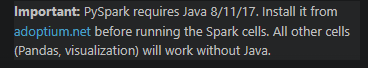

In [61]:
# I already have it installed in my laptop
%pip install pyspark --quiet

Note: you may need to restart the kernel to use updated packages.


### <span style="color: green;"><u>Creating the Spark session</u></span>

### <b>SparkSession</b>
##### <span style="color: yellow;">SparkSession is the single entry point to all Spark functionality. The master("local[*]") setting tells Spark to run on the local machine using all available CPU cores, simulating a distributed environment. This is ideal for development and for datasets that fit on a single node</span>

In [62]:
# this process took about 60 seconds in my lap
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("CitiBike_BigData_Analysis")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version  : {spark.version}")
print(f"Cores available: {spark.sparkContext.defaultParallelism}")

Spark version  : 4.1.1
Cores available: 16


### <span style="color: green;"><u>Loading the dataset with pyspark</u></span>

### <b>Reading citibike.csv dataset</b>
##### <span style="color: yellow;">Pandas read_csv immediately loads all data into mempry. Spark's read.csv instead builds a lazy execution plan, it means that nothing is actually read until an action such as .count() or .show() is called.</span>
##### <span style="color: yellow;">This lazy evaluation allows Spark's Catalyst optimizer to analyse the full pipeline and eliminate redundant steps before touching disk, which is critical when dealing with datasets that span hundreds of gigabytes</span>

In [63]:
import time

# spark reads the csv lazily
spark_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("citibike.csv")
)

# the method .cache() pins this dataframe in memory after the first action
spark_df.cache()

print("Schema:")
spark_df.printSchema()

Schema:
root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)



In [64]:
# .count() is the first action, spark now physically reads the file
t0 = time.time()
row_count = spark_df.count()
print(f"Rows loaded : {row_count:,}")
print(f"Columns     : {len(spark_df.columns)}")
print(f"Load time   : {time.time()-t0:.2f}s")
spark_df.show(5, truncate=True)

Rows loaded : 1,000,000
Columns     : 13
Load time   : 0.15s
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------+------------+-----------------+-----------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|  start_lat|   start_lng|          end_lat|          end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------+------------+-----------------+-----------------+-------------+
|8CA3B6A78AF59CA5|electric_bike|2026-02-06 17:20:...|2026-02-06 17:24:...| Bond St & Bergen St|         4404.10| Amity St & Court St|       4488.10| 40.6849668|-73.98620772|40.68841885589487|-73.9931417101234|       member|
|C6426029C22F971F|electric_bike|2026-02-04 

### <span style="color: green;"><u>Transformations with Pyspark</u></span>

### <b>Computing trip duration and time features</b>
##### <span style="color: yellow;">In Pandas we subtract two datetime Series with the "-" operator. In the other hand, with Pyspark we must use the built-in SQL functions from pyspark.sql.functions. The unix_timestamp() function converts a timestamp string to epoch seconds, and withColumn() appends the result as a new column (in pandas it would be something like df["new_col"] = ), every transformation returns a new dataframe; Spark dataframes are immutable</span>

In [65]:
# compute trip duration in minutes
spark_df = spark_df.withColumn(
    "duration_min",
    (F.unix_timestamp("ended_at") - F.unix_timestamp("started_at")) / 60
)

# extract hour of day from the start timestamp
spark_df = spark_df.withColumn(
    "hour",
    F.hour(F.to_timestamp("started_at"))
)

# binary flag: is this a rush-hour trip?
rush_hours = [7, 8, 9, 16, 17, 18, 19]
spark_df = spark_df.withColumn(
    "is_rush_hour",
    F.col("hour").isin(rush_hours).cast("int")
)

# remove rows with invalid or null duration
spark_df_clean = spark_df.filter(
    F.col("duration_min").isNotNull() & (F.col("duration_min") > 0)
)

spark_df_clean.select(
    "started_at", "ended_at", "duration_min", "hour", "is_rush_hour"
).show(5)

+--------------------+--------------------+------------------+----+------------+
|          started_at|            ended_at|      duration_min|hour|is_rush_hour|
+--------------------+--------------------+------------------+----+------------+
|2026-02-06 17:20:...|2026-02-06 17:24:...| 4.216666666666667|  17|           1|
|2026-02-04 12:02:...|2026-02-04 12:10:...| 7.983333333333333|  12|           0|
|2026-02-11 19:37:...|2026-02-11 19:43:...|              5.95|  19|           1|
|2026-02-01 12:31:...|2026-02-01 12:39:...|               7.5|  12|           0|
|2026-02-13 05:49:...|2026-02-13 06:09:...|19.833333333333332|   5|           0|
+--------------------+--------------------+------------------+----+------------+
only showing top 5 rows


### <b>Aggregation</b>
##### <span style="color: yellow;">Spark's groupBy().agg() is the distributed equivalent of Pandas groupby().agg(). Each partition computes a local partial aggregate independently; Spark then performs a shuffle, redistributing rows by key across workers, to combine partition results into the final answer.</span>
##### <span style="color: yellow;">The shuffle is the most expensive step in distributed processing, which is why minimising the number of distinct group keys reduces execution time on a cluster</span>

In [66]:
member_stats = (
    spark_df_clean
    .groupBy("member_casual")
    .agg(
        F.count("*").alias("total_trips"),
        F.round(F.avg("duration_min"), 2).alias("avg_duration_min"),
        F.round(F.max("duration_min"), 2).alias("max_duration_min"),
        F.round(F.stddev("duration_min"), 2).alias("stddev_duration_min")
    )
    .orderBy("total_trips", ascending=False)
)

print("=== Trip Statistics by Member Type ===")
member_stats.show()

=== Trip Statistics by Member Type ===
+-------------+-----------+----------------+----------------+-------------------+
|member_casual|total_trips|avg_duration_min|max_duration_min|stddev_duration_min|
+-------------+-----------+----------------+----------------+-------------------+
|       member|     914503|           11.16|         1499.95|              34.11|
|       casual|      85497|           16.94|         1499.93|              54.41|
+-------------+-----------+----------------+----------------+-------------------+



### <b>Top 10 busiest start stations</b>
##### <span style="color: yellow;">This is the Spark equivalent of Pandas value_counts().head(10). Spark's groupBy + count + orderBy chain is more verbose but distributes the counting operation across all partitions in parallel. On a real cluster, each worker node counts its local partition, then the driver merges and sorts the partial results</span>

In [67]:
top_stations = (
    spark_df_clean
    .groupBy("start_station_name")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_count", ascending=False)
    .limit(10)
)

print("=== Top 10 Busiest Start Stations ===")
top_stations.show(truncate=False)

=== Top 10 Busiest Start Stations ===
+------------------------+----------+
|start_station_name      |trip_count|
+------------------------+----------+
|W 21 St & 6 Ave         |4496      |
|Pier 61 at Chelsea Piers|4425      |
|Lafayette St & E 8 St   |3810      |
|W 31 St & 7 Ave         |3694      |
|11 Ave & W 41 St        |3619      |
|9 Ave & W 33 St         |3519      |
|Broadway & E 14 St      |3226      |
|E 17 St & Broadway      |3146      |
|Ave A & E 14 St         |3101      |
|W 43 St & 10 Ave        |3035      |
+------------------------+----------+



### <b>Hourly trip distribution</b>
##### <span style="color: yellow;">Grouping 1 million trips by the 24 hours of the day reveals the daily rhythm of the bike-sharing system. Commuter peaks at hours 8 and 17 confirm the member vs casual behavioural split seen throughout this notebook</span>

In [68]:
hourly_trips = (
    spark_df_clean
    .groupBy("hour")
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("duration_min"), 2).alias("avg_duration_min")
    )
    .orderBy("hour")
)

print("=== Trips and Avg Duration by Hour of Day ===")
hourly_trips.show(24)

=== Trips and Avg Duration by Hour of Day ===
+----+----------+----------------+
|hour|trip_count|avg_duration_min|
+----+----------+----------------+
|   0|     11524|           11.71|
|   1|      6445|            13.2|
|   2|      4395|           12.08|
|   3|      3282|           12.55|
|   4|      3927|           11.46|
|   5|      9984|            8.82|
|   6|     23969|            9.56|
|   7|     45678|           11.01|
|   8|     70273|            11.5|
|   9|     55929|           11.59|
|  10|     44784|           11.48|
|  11|     46371|           11.86|
|  12|     51694|           11.87|
|  13|     56311|           12.17|
|  14|     63091|           12.24|
|  15|     69343|           12.33|
|  16|     77454|           12.12|
|  17|     95500|           12.12|
|  18|     82146|            11.4|
|  19|     59897|            11.1|
|  20|     41978|           11.13|
|  21|     31753|           11.78|
|  22|     25539|           11.05|
|  23|     18733|           11.03|
+----+---

### <span style="color: green;"><u>Performance experiment between Pyspark and Pandas</u></span>

### <b>Benchmarking the same aggregation pipeline</b>
##### <span style="color: yellow;">I will time the identical pipeline,read csv-file, compute trip duration, group by member type, compute average, on both Pandas and Pyspark. on a single machine with <b>1 million rows, Pandas</b> is often faster because it avoids Spark's coordination overhead. However, at <b>100 million or 1 billion rows</b> distributed across a cluster, <b>Spark</b> would outperform Pandas by orders of magnitude because Pandas cannot scale beyond one machine's memory</span>

In [69]:
import pandas as pd
import time

# ==> PANDAS PIPELINE
print("Running Pandas pipeline...")
pd_start = time.time()

df_pd = pd.read_csv("citibike.csv", low_memory=False)
df_pd["duration_min"] = (
    pd.to_datetime(df_pd["ended_at"]) - pd.to_datetime(df_pd["started_at"])
).dt.total_seconds() / 60
df_pd = df_pd[df_pd["duration_min"] > 0]
pd_result = df_pd.groupby("member_casual")["duration_min"].agg(["count", "mean"])

pd_elapsed = time.time() - pd_start
print(pd_result.round(2))
print(f"\nPandas elapsed  : {pd_elapsed:.2f}s")

# ==> PYSPARK PIPELINE
print("\nRunning PySpark pipeline...")
sp_start = time.time()

sp_bench = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("citibike.csv")
    .withColumn(
        "duration_min",
        (F.unix_timestamp("ended_at") - F.unix_timestamp("started_at")) / 60
    )
    .filter(F.col("duration_min") > 0)
    .groupBy("member_casual")
    .agg(
        F.count("*").alias("count"),
        F.round(F.avg("duration_min"), 2).alias("mean_duration_min")
    )
    .collect()
)

sp_elapsed = time.time() - sp_start
for row in sp_bench:
    print(dict(row.asDict()))
print(f"\nPySpark elapsed : {sp_elapsed:.2f}s")

# ==> SUMMARY TABLE
print("\n" + "=" * 44)
print("  BENCHMARK SUMMARY")
print("=" * 44)
print(f"  Pandas  : {pd_elapsed:.2f}s")
print(f"  PySpark : {sp_elapsed:.2f}s")
winner = "Pandas" if pd_elapsed < sp_elapsed else "PySpark"
ratio  = max(pd_elapsed, sp_elapsed) / min(pd_elapsed, sp_elapsed)
print(f"  Faster on this machine : {winner}  ({ratio:.1f}x)")
print("=" * 44)

Running Pandas pipeline...
                count   mean
member_casual               
casual          85497  16.94
member         914503  11.16

Pandas elapsed  : 3.66s

Running PySpark pipeline...
{'member_casual': 'casual', 'count': 85497, 'mean_duration_min': 16.94}
{'member_casual': 'member', 'count': 914503, 'mean_duration_min': 11.16}

PySpark elapsed : 0.72s

  BENCHMARK SUMMARY
  Pandas  : 3.66s
  PySpark : 0.72s
  Faster on this machine : PySpark  (5.1x)


### <span style="color: green;"><u>Visualization</u></span>

### <b>Hourly trip volume, Member vs Casual</b>
##### <span style="color: yellow;">Pyspark dataframes cannot be plotted directly with Matplotlib because the data lives across distributed partitions. The correct Big Data visualization pattern is: aggregate in Spark (producing a small summary table), then call .toPandas() to collect only that summary to the driver node, and finally plot with Matplotlib. This avoids transferring millions of rows, only the 48-row summary crosses the network</span>

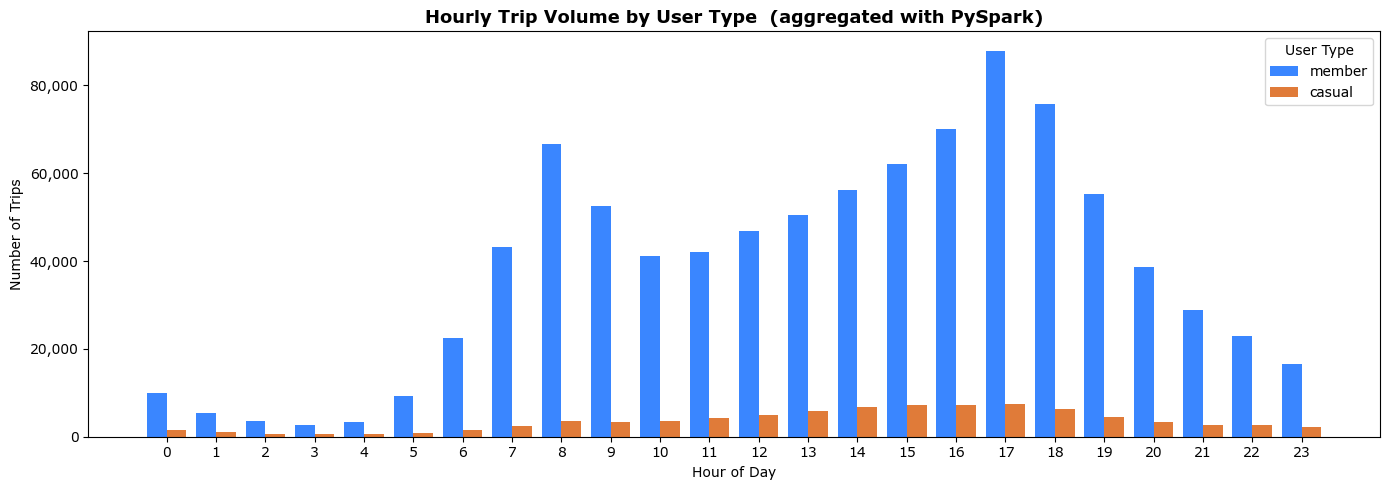

In [70]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# aggregate in spark: 48 rows (24 hours x 2 user types)
hourly_by_type = (
    spark_df_clean
    .groupBy("hour", "member_casual")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("hour")
)

# collect the tiny summary to the driver for plotting
hourly_pd = hourly_by_type.toPandas()
pivot = hourly_pd.pivot(
    index="hour", columns="member_casual", values="trip_count"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(pivot))
width = 0.4
ax.bar(x - width/2, pivot.get("member", 0), width, label="member", color="#3a86ff")
ax.bar(x + width/2, pivot.get("casual", 0), width, label="casual",  color="#e07b39")
ax.set_title(
    "Hourly Trip Volume by User Type  (aggregated with PySpark)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.set_xticks(x)
ax.set_xticklabels(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(title="User Type")
plt.tight_layout()
plt.show()

### <b>Average trip duration by hour and user type</b>
##### <span style="color: yellow;">Members show short, consistent durations throughout the day, confirming a commute pattern. Casual riders have longer and more variable trips peaking in the afternoon, typical leisure behaviour.</span>
##### <span style="color: yellow;">Both insights were produced by a distributed Spark aggregation and transferred to Matplotlib as a 48-row Pandas dataset</span>

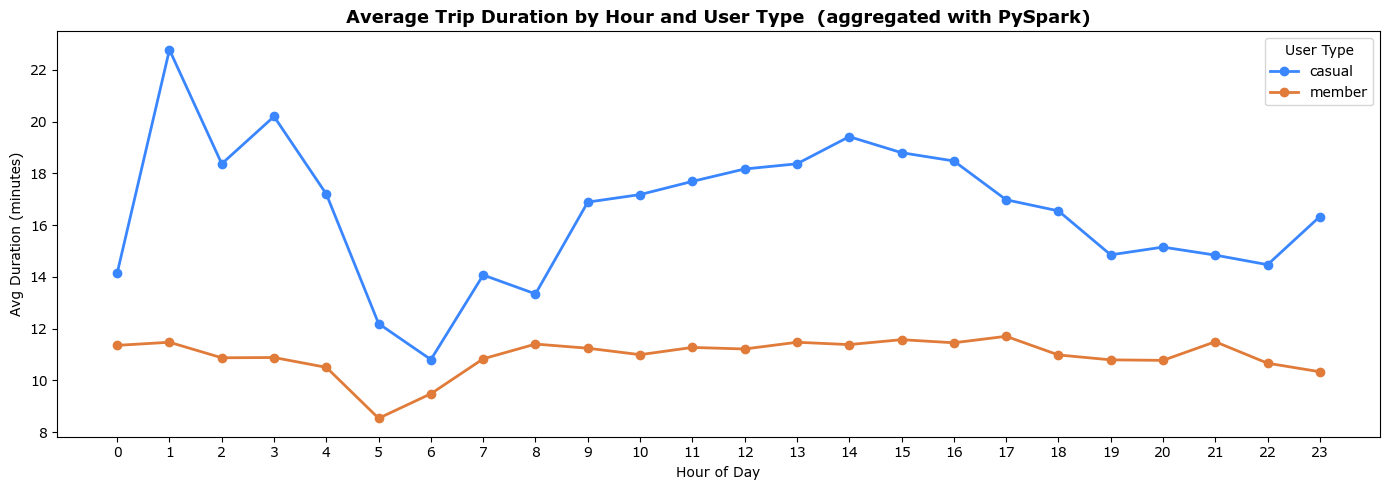

In [71]:
avg_dur = (
    spark_df_clean
    .groupBy("hour", "member_casual")
    .agg(F.round(F.avg("duration_min"), 2).alias("avg_duration"))
    .orderBy("hour")
)

dur_pd    = avg_dur.toPandas()
pivot_dur = dur_pd.pivot(
    index="hour", columns="member_casual", values="avg_duration"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
for col, colour in zip(pivot_dur.columns, ["#3a86ff", "#e07b39"]):
    ax.plot(pivot_dur.index, pivot_dur[col],
            marker="o", linewidth=2, color=colour, label=col)
ax.set_title(
    "Average Trip Duration by Hour and User Type  (aggregated with PySpark)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Duration (minutes)")
ax.set_xticks(range(24))
ax.legend(title="User Type")
plt.tight_layout()
plt.show()

### <span style="color: green;"><u>Discussion about Pyspark vs Pandas</u></span>

### <b>Syntax differences</b>
##### <span style="color: yellow;">Pandas uses Python-native operators: arithmetic between columns, boolean masks with &, and method chaining that feels natural to Python developers.</span>
##### <span style="color: yellow;">PySpark requires importing SQL functions like F.col, F.avg, F.unix_timestamp and wrapping every operation in withColumn() or filter().</span>
##### <span style="color: yellow;">The verbosity is intentional, each function call is a node in the DAG that Spark can serialize, ship to a remote worker, and execute in parallel</span>

| Operation | Pandas | PySpark |
|---|---|---|
| Duration | `df["end"] - df["start"]` | `F.unix_timestamp("end") - F.unix_timestamp("start")` |
| New column | `df["col"] = expr` | `.withColumn("col", expr)` |
| Filter | `df[df["col"] > 0]` | `.filter(F.col("col") > 0)` |
| Group + avg | `.groupby().agg({"col":"mean"})` | `.groupBy().agg(F.avg("col"))` |
| Plot | `df.plot()` | `.toPandas().plot()` |

### <b>Execution model differences</b>
##### <span style="color: yellow;"><b>Eager vs Lazy:</b> <b>Pandas is eager</b>. every line executes immediately and returns a result. <b>Spark is lazy</b>. transformations like withColumn and filter only build a DAG; nothing runs until an action (count, show, collect, toPandas) is called. This allows Spark's catalyst optimizer to reorder and fuse operations before execution, often eliminating redundant passes over the data</span>
##### <span style="color: yellow;"><b>Single machine vs distributed:</b> <b>Pandas requires the entire dataset</b> to fit in memory on one machine. <b>Spark partitions the data</b>, can spill partitions to disk when RAM is exhausted, and can distribute across hundreds of nodes.</span>
##### <span style="color: yellow;">The 1-million ish row citibike dataset fits in memory, so Pandas was faster on my laptop. At 100 million rows on a cluster, Spark would be orders of magnitude faster because each node processes its own partition in parallel</span>
##### <span style="color: yellow;"><b>When to use each:</b> Use <b>Pandas when data fits comfortably in RAM</b>. Use <b>Spark when data exceeds RAM</b>, when parallelism is needed for speed, or when processing must scale to a cluster in production</span>

### <b>Some insights from the analysis</b>
##### <span style="color: yellow;">==> Members dominate with 91.4% of trips and use the system as a commuter tool, short trips clustered at rush hours 8 and 17</span>
##### <span style="color: yellow;">==> Casual riders take longer trips on average, peaking in the afternoon, consistent with leisure and tourist usage</span>
##### <span style="color: yellow;">==> The top 10 stations account for a disproportionate share of departures, pointing to high-priority docking infrastructure that must remain fully stocked</span>
##### <span style="color: yellow;">==> The same aggregations that would require minutes in Pandas on a 100M-row dataset would complete in seconds on a 10-node Spark cluster, demonstrating the core value proposition of distributed Big Data processing</span>